<a href="https://colab.research.google.com/github/jaityagi63/ml_scratch/blob/master/rideg_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_diabetes()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)
print(f"Shape of scaled_x_train: {scaled_x_train.shape}")
print(f"Shape of scaled_x_test: {scaled_x_test.shape}")

Shape of scaled_x_train: (353, 10)
Shape of scaled_x_test: (89, 10)


In [7]:
df = pd.DataFrame(scaled_x_train, columns=x_train.columns)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,1.498365,1.061370,0.219902,1.138874,0.728473,1.055893,-0.824451,0.711038,0.547482,-0.061449
1,-0.228858,1.061370,-0.419366,-0.710591,-0.424929,0.272425,-1.529791,1.484286,-0.019757,0.367236
2,0.085182,-0.942179,1.018987,1.992473,-0.309589,-0.326699,-0.119111,-0.062210,0.331237,-0.318660
3,-0.621409,-0.942179,-0.784662,-0.639458,-1.174640,-1.215508,0.664600,-0.835458,-1.069682,-2.719299
4,-0.542899,-0.942179,-1.423930,-1.706457,-0.799784,-1.110167,1.291569,-1.608706,-0.802859,-0.918820


In [8]:
model = Ridge(alpha=0.8)
model.fit(scaled_x_train, y_train)

Ridge(alpha=0.8)

In [9]:
y_pred = model.predict(scaled_x_test)

In [10]:
r2_score(y_test, y_pred)
#

0.45392071159466973

In [11]:
alphas = np.logspace(-4, 4, 100)
print(f"First 5 alpha values: {alphas[:5]}")
print(f"Number of alpha values: {len(alphas)}")

First 5 alpha values: [0.0001     0.00012045 0.00014508 0.00017475 0.00021049]
Number of alpha values: 100


In [36]:
r2_scores = []
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(scaled_x_train, y_train)
    y_pred = model.predict(scaled_x_test)
    r2_scores.append(r2_score(y_test, y_pred))

print(f"Number of R2 scores calculated: {len(r2_scores)}")
print(f"First 5 R2 scores: {r2_scores[:5]}")

Number of R2 scores calculated: 100
First 5 R2 scores: [0.45260298762466267, 0.45260303356446185, 0.4526030888979934, 0.4526031555458041, 0.45260323582097306]


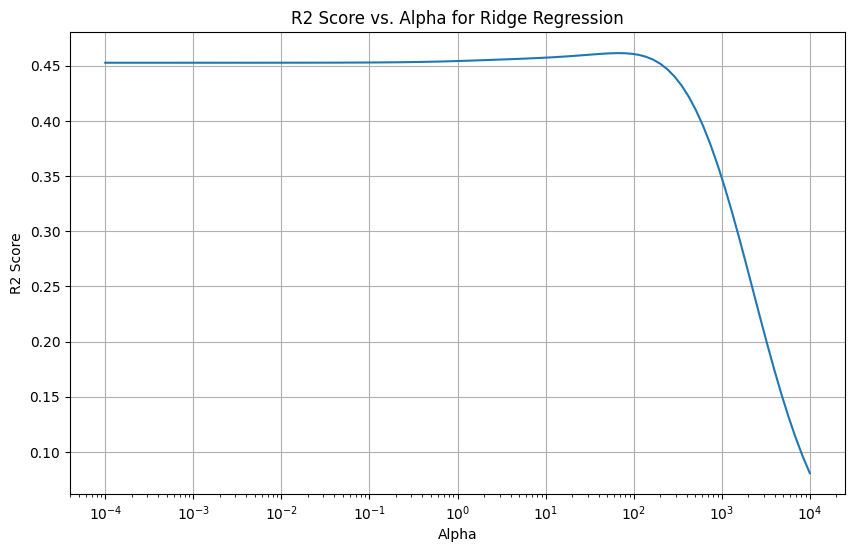

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_scores)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('R2 Score vs. Alpha for Ridge Regression')
plt.grid(True)
plt.show()


In [14]:
!pip install statsmodels
import statsmodels.api as sm

reg = sm.OLS(y_train, sm.add_constant(scaled_x_train)).fit()

In [15]:
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     38.25
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           5.41e-50
Time:                        10:23:21   Log-Likelihood:                -1906.1
No. Observations:                 353   AIC:                             3834.
Df Residuals:                     342   BIC:                             3877.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        153.7365      2.896     53.083      0.0

only for single-variable regression

In [16]:
# class CustomRidge:
#   def __init__(self, rige=0.05):
#     self.rige = rige
#     self.intercept_ = None
#     self.coeff_ = None

#   def fit(self, scaled_x_train, y_train):
#     y_avg = y_train.mean()
#     x_avg = scaled_x_train.mean(axis=0)

#     num = np.sum((scaled_x_train - x_avg) * (y_train.values.reshape(-1,1) - y_avg), axis=0)
#     den = np.sum((scaled_x_train - x_avg)**2, axis=0)

#     self.coeff_ = num / (den + self.rige)
#     self.intercept_ = y_avg - np.dot(self.coeff_, x_avg)
#     print(f"Coefficients: {self.coeff_}")
#     print(f"Intercept: {self.intercept_}")
#     return self.coeff_, self.intercept_

#   def predict(self, scaled_x_test):
#     return np.dot(scaled_x_test, self.coeff_) + self.intercept_

In [17]:
# sk_ridge_model = Ridge(alpha=0.8)
# sk_ridge_model.fit(scaled_x_train, y_train)
# y_pred = ridge.predict(scaled_x_test)
# r2_score(y_test, y_pred)

In [48]:
class my_ridge:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coeff_ = None
        self.intercept_ = None

    def fit(self, x_train, y_train):

        X = np.c_[np.ones(x_train.shape[0]), x_train]

        I = np.eye(X.shape[1])
        I[0,0] = 0

        betas = np.linalg.inv(X.T @ X + self.alpha * I) @ X.T @ y_train

        self.intercept_ = betas[0]
        self.coeff_ = betas[1:]

        # Removed print statements for cleaner output during hyperparameter tuning
        # print("Coefficients:", self.coeff_)
        # print("Intercept:", self.intercept_)

    def predict(self, x_test):
        return x_test @ self.coeff_ + self.intercept_

In [40]:
ridge = my_ridge(alpha=0.8)
ridge.fit(scaled_x_train, y_train)

Coefficients: [  1.79871457 -11.46008005  25.71495415  16.75081003 -36.24260969
  18.26982199   4.06150441  11.98614554  31.9873372    2.43960975]
Intercept: 153.73654390934846


In [41]:
y_pred = ridge.predict(scaled_x_test)

In [42]:
r2_score(y_test, y_pred)

0.45392071159466973

In [49]:
alphas = np.logspace(0.1, 4, 100)
print(f"First 5 alpha values: {alphas[:5]}")
print(f"Number of alpha values: {len(alphas)}")

First 5 alpha values: [1.25892541 1.37845927 1.50934277 1.65265354 1.80957154]
Number of alpha values: 100


In [50]:
r2_scores = []
for alpha in alphas:
    model = my_ridge(alpha=alpha)
    model.fit(scaled_x_train, y_train)
    y_pred = model.predict(scaled_x_test)
    r2_scores.append(r2_score(y_test, y_pred))

print(f"Number of R2 scores calculated: {len(r2_scores)}")
print(f"First 5 R2 scores: {r2_scores[:5]}")

Number of R2 scores calculated: 100
First 5 R2 scores: [0.4543999663933639, 0.45450466944170553, 0.4546117002672847, 0.45472076631015745, 0.45483157695596554]


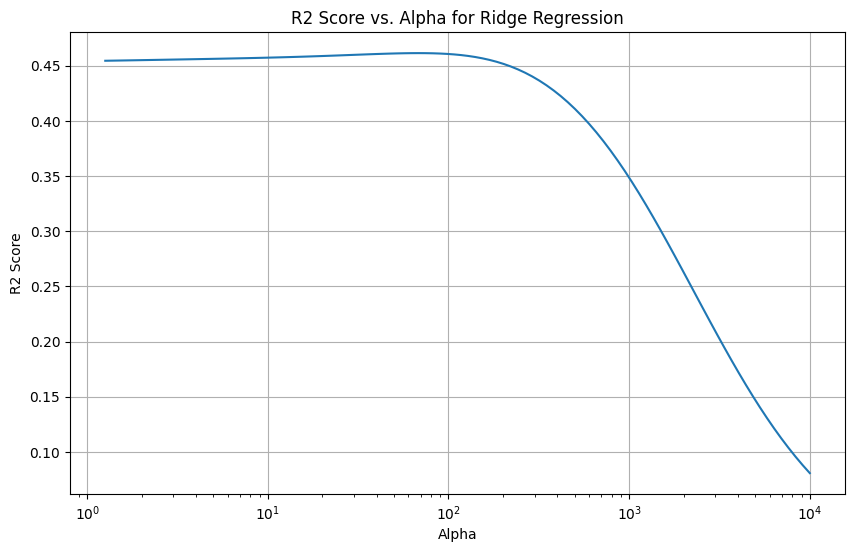

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_scores)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('R2 Score vs. Alpha for Ridge Regression')
plt.grid(True)
plt.show()